In [1]:
using Pkg
Pkg.activate("..")
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()
import HybridDynamics as HD
import Plots as plt
using LaTeXStrings

  Activating project at `c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl`
     Project No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Project.toml`
    Manifest No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Manifest.toml`
Precompiling packages...
   2046.5 ms  ✓ HybridDynamics
  1 dependency successfully precompiled in 3 seconds. 110 already precompiled.


In [2]:
# defining the Fuller constant
const ξ = sqrt((sqrt(33) - 1) / 24)

0.44462356018593735

In [3]:
# Define the vector fields
# F is active when H(x) > 0 (Region G_ -> u = -1)
function F(x)
    return [x[2], -1.0]
end

F (generic function with 1 method)

In [4]:
# G is active when H(x) < 0 (Region G_+ -> u = +1)
function G(x)
    return [x[2], 1.0]
end

G (generic function with 1 method)

In [5]:
# Defining the guard
function H(x)
    return x[1] + sign(x[2]) * ξ * x[2]^2
end

H (generic function with 1 method)

In [6]:
# Define the Normal
function N(x)
    return [1.0, 2.0 * ξ * abs(x[2])]
end

N (generic function with 1 method)

In [7]:
sys = HD.FilippovSystem(F, G, H, N)

HybridDynamics.FilippovSystem{typeof(F), typeof(G), typeof(H), typeof(N)}(Main.F, Main.G, Main.H, Main.N)

In [13]:
# Setting up two trajectories to plot later!
x0_1 = [0.15, 0.35]
prob1 = HD.prob(sys, x0_1, (0.0, 5.0))
sol1 = HD.solve(prob1, HD.RK4())

x0_2 = [-0.15, -0.35] 
prob2 = HD.prob(sys, x0_2, (0.0, 5.0))
sol2 = HD.solve(prob2, HD.RK4())


HybridDynamics.FilippovSol{Vector{Float64}, Vector{Vector{Float64}}, Vector{Vector{Float64}}, Vector{Float64}, Vector{Float64}, Vector{Int64}}([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.07, 0.08, 0.09  …  4.910622667385904, 4.920622667385904, 4.9306226673859035, 4.940622667385903, 4.950622667385903, 4.960622667385903, 4.970617505300877, 4.980617505300877, 4.990617505300877, 5.0], [[-0.15, -0.35], [-0.15345, -0.33999999999999997], [-0.1568, -0.32999999999999996], [-0.16005, -0.31999999999999995], [-0.16319999999999998, -0.30999999999999994], [-0.16624999999999998, -0.29999999999999993], [-0.1692, -0.2899999999999999], [-0.17204999999999998, -0.2799999999999999], [-0.17479999999999998, -0.2699999999999999], [-0.17744999999999997, -0.2599999999999999]  …  [7.209994903122454e-5, 0.00959910269964654], [0.00011809097602768993, -0.00040089730035345987], [6.408200302415534e-5, -0.01040089730035346], [1.0073030020620731e-5, -0.00040089730035345987], [5.606405701708614e-5, 0.009

In [14]:
# Extracting states for both trajectories. 
x1 = [state[1] for state in sol1.x]
y1 = [state[2] for state in sol1.x]

x2 = [state[1] for state in sol2.x]
y2 = [state[2] for state in sol2.x];

In [15]:
# Generating the switchig manifold (guard) over what the plot will show
y_surf = range(-0.5, 0.5, length=200)
x_surf = [-sign(y) * ξ * y^2 for y in y_surf];


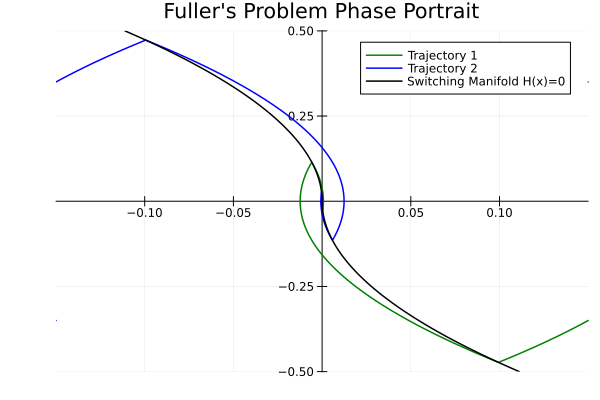

In [16]:
# Making the plot. 
plt.plot(x1, y1, 
    title="Fuller's Problem Phase Portrait", 
    label="Trajectory 1", 
    lw=1.5, color=:green,
    framestyle=:origin,      # Forces the x and y axes to cross at (0,0)
    xlims=(-0.15, 0.15),     # Narrows the X bounds to stretch the curves horizontally (so we can see what happens)
    ylims=(-0.5, 0.5),       # Keeps the Y bounds tall
    grid=true,
    legend=:topright
)
plt.plot!(x2, y2, label="Trajectory 2", lw=1.5, color=:blue)
plt.plot!(x_surf, y_surf, label="Switching Manifold H(x)=0", color=:black, lw=1.5)